In [2]:
from dynamicTasteDistortion.scripts.vis import plot_metric_comparison, plot_metrics_smoothed

Objetivo: Verificar se tem algum comportamento da simulação que faz sentido eu alterar pra visualizar melhor o efeito de distorção de preferencias


- [] Comparando h_0 com itens interagidos, não necessariamente recomendados.
- [] h_0 com o bootstrapped_df?
- [] Aumentar quantidade de interações observadas? Ex: tempo muito maior, aumentar a quantidade de interações por ciclo
- [] Evitar mascarar itens previamente vistos? Mas isso ja começa a fugir do que to interessado em pesquisar

- [] Parar de fazer esse reset de cliques? Posso pegar o bootstrapped_df, acumular umas 10 rodadas de warming up, e depois trocar pra recomendação mesmo. E ir acumulando os cliques. Eu acho que não vai ser um problema esse reset...

- [] Retreino frequente? Isso pode ser algo bem interessante. Tipo, sufficient retraining is enough to stop taste distortion em comparação com calibração.


In [3]:

# Versões comparando historico com 



random_rec_alpha_0_1 = "experiments/evolving_preferences/random_rec_with_oracle_experiment_alpha_0_1.yaml"
most_popular_alpha_0_1 = "experiments/evolving_preferences/most_popular_with_oracle_experiment_alpha_0_1.yaml"

# Versões sem evolução de preferências (alpha = 0)
bpr_debiased = "experiments/bpr_with_oracle_experiment.yaml"
random_rec = "experiments/random_rec_with_oracle_experiment.yaml"
most_popular = "experiments/most_popular_with_oracle_experiment.yaml"

# Versões com evolução de preferências (Porém, sem esquecimento)


bpr_debiased_alpha_0_1 = "experiments/evolving_preferences/bpr_unbiased_uncalibrated_alpha_0_1.yaml"
random_rec_alpha_0_1 = "experiments/evolving_preferences/random_rec_with_oracle_experiment_alpha_0_1.yaml"
most_popular_alpha_0_1 = "experiments/evolving_preferences/most_popular_with_oracle_experiment_alpha_0_1.yaml"

## Teste 1 - Resetando conhecimento - Bootstrapped df x h_0


In [4]:
bpr_with_evolving_user_profile= "experiments/ablation_v2/bpr_uncalibrated_comparing_with_round_df.yaml"
bpr_debiased_alpha_0_1 = "experiments/evolving_preferences/bpr_unbiased_uncalibrated_alpha_0_1.yaml"



Curva da esquerda:

* Atualiza as preferencias do usuario sempre que for retreinar (boostrapped_df como referencia)
* Reseta o boostrapped_df

Curva da direita:

* Compara sempre com o h_0
* reseta o boostrapped_df

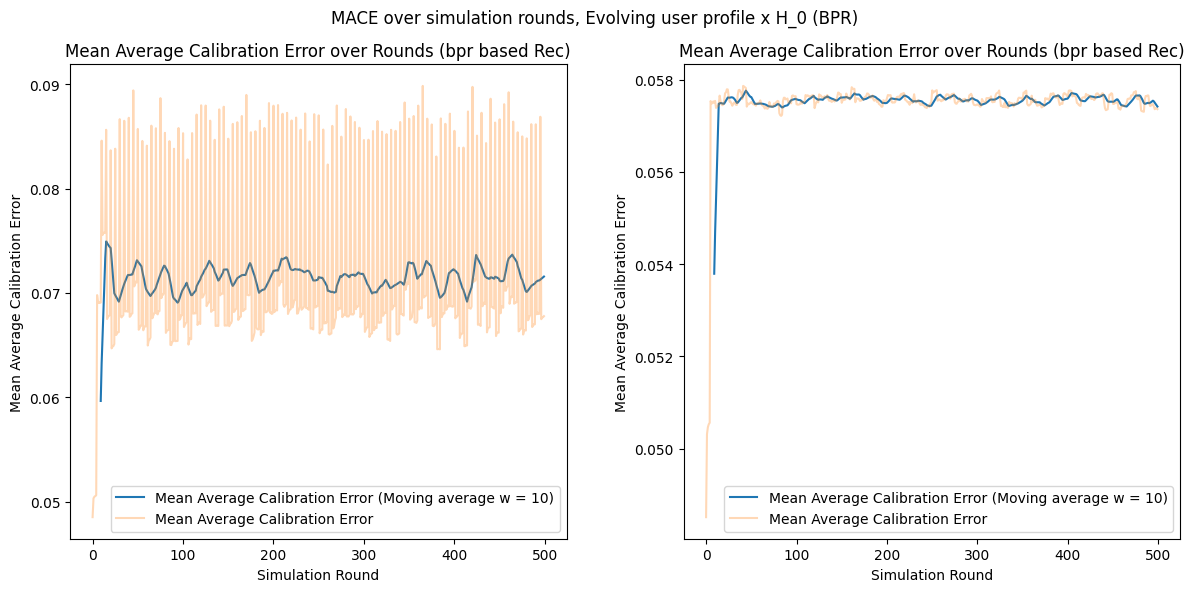

In [5]:
plot_metric_comparison(bpr_with_evolving_user_profile, bpr_debiased_alpha_0_1, metric_name="mace", title="MACE over simulation rounds, Evolving user profile x H_0 (BPR)", graph="line", plot_retrain_points=False,  window_size=10)

## Teste 2 - Atualizando a preferencia do usuário, mas acumulando cliques

In [7]:
bpr_with_evolving_user_profile_without_reset = "experiments/ablation_v2/bpr_uncalibrated_comparing_with_round_df_without_reset.yaml"
bpr_no_reset_compare_to_h0 = "experiments/ablation_v2/bpr_uncalibrated_comparing_with_h_0_no_reset.yaml"


Grafico da direita:

* Compara com o h_0
* Acumula  cliques


Grafico da esquerda:

* Atualiza perfil do usuario ao longo do tempo
* Acumula cliques

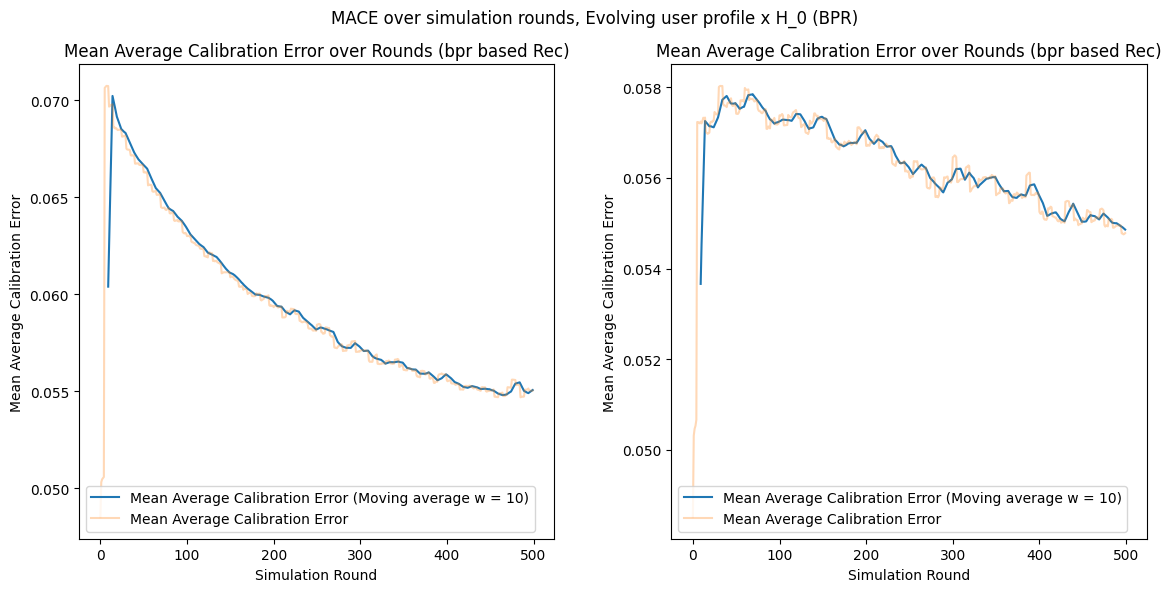

In [11]:
plot_metric_comparison(bpr_with_evolving_user_profile_without_reset, bpr_no_reset_compare_to_h0, metric_name="mace", title="MACE over simulation rounds, Evolving user profile x H_0 (BPR)", graph="line", plot_retrain_points=False,  window_size=10)

Talvez o número de interações em cada turno seja muito baixo, o que faz o MACE estabilizar?

## Teste 3 - Acumulando cliques, mas treinando só nas ultimas L rodadas

In [5]:
bor_train_reset = "experiments/ablation_v2/bpr_uncalibrated_comparing_with_h_0_no_reset_no_full_retrain.yaml"

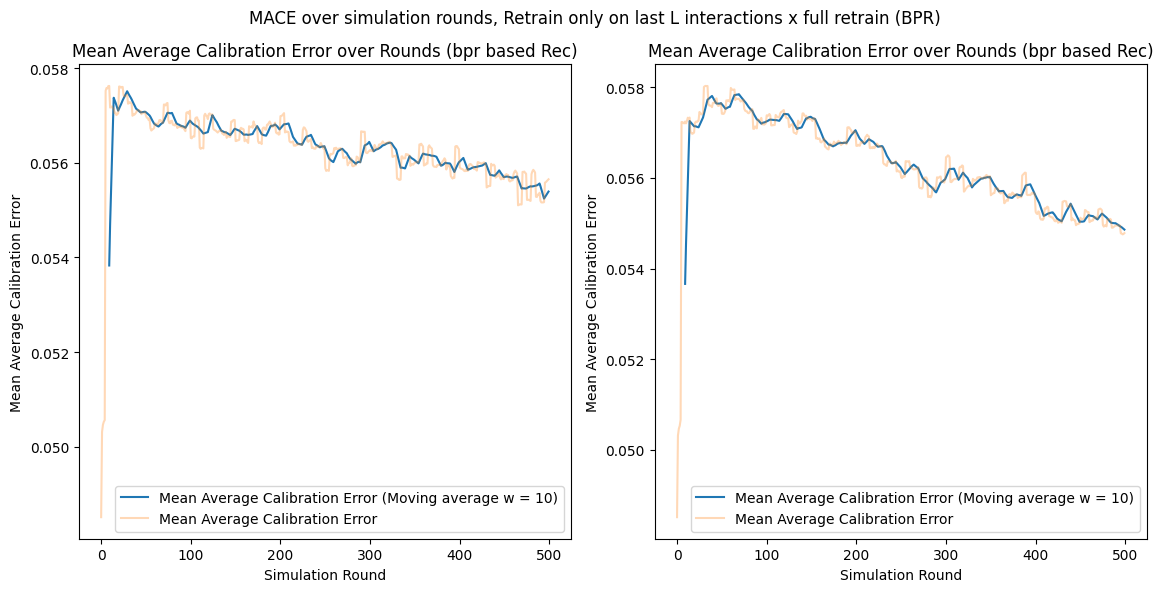

In [9]:
plot_metric_comparison(bor_train_reset, bpr_no_reset_compare_to_h0, metric_name="mace", title="MACE over simulation rounds, Retrain only on last L interactions x full retrain (BPR)", graph="line", plot_retrain_points=False,  window_size=10)

Isso reforça a hipotese de que os itens estarem estaveis mostra que o modelo só não ta aprendendo. Ele é consistente, mas ta recomendando da memsa maneira.

Essa versão debaixo foi usando o bootstrapped_df como coldstart